<a href="https://colab.research.google.com/github/biopharma26/PracticeNotebooks/blob/main/4.4%20RNA_ncRNA_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RNA Sequence Classification & ncRNA Biological Role
###

**Input sequence (given):**
```
ACGUACGUACGUAUGUUCAAGCAGAAGAACACCAACAACACCAACACCAACAACACCAACAACCAGCAGCAGCAAUAAGCUAGCUAGCUAGCUAGCAAAA
```

**Approach.** A single ~100 nt sequence with no metadata cannot be classified by name-lookup alone — we have to
build the evidence the way a real ncRNA-annotation pipeline would (think Rfam/Infernal, CPC2/CPAT, RNAfold):

1. Composition & length statistics
2. Tandem-repeat / low-complexity scan
3. ORF discovery + coding-potential estimate
4. Minimum free energy (MFE) secondary structure (ViennaRNA `RNAfold`)
5. Motif scan for class-diagnostic signatures (tRNA `CCA` end, snoRNA C/D- and H/ACA-boxes, poly-A signal, pre-miRNA-style hairpin)
6. A transparent, weighted rule-based classifier that scores every major ncRNA class against the evidence
7. (Optional, needs live internet in Colab) homology search against NCBI/Rfam to corroborate

Run all cells top to bottom (**Runtime → Run all**). Only Part 8 needs internet access; everything else is fully offline/reproducible.


In [1]:
# 0. Setup
!pip -q install ViennaRNA biopython pandas matplotlib >/dev/null
import re, textwrap
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import RNA  # ViennaRNA python bindings
from Bio.Seq import Seq

pd.set_option('display.max_colwidth', None)
print("Environment ready.")

Environment ready.


## 1. Load sequence & basic composition

In [2]:
seq = "ACGUACGUACGUAUGUUCAAGCAGAAGAACACCAACAACACCAACAACACCAACAACACCAACAACCAGCAGCAGCAAUAAGCUAGCUAGCUAGCUAGCAAAA"
# NOTE: verify against the literal string you were given; re-paste here if it differs.
seq = "ACGUACGUACGUAUGUUCAAGCAGAAGAACACCAACAACACCAACACCAACAACACCAACAACCAGCAGCAGCAAUAAGCUAGCUAGCUAGCUAGCAAAA"

assert set(seq) <= set("ACGU"), "Sequence contains non-standard RNA characters"
L = len(seq)
counts = Counter(seq)
gc = (counts['G'] + counts['C']) / L * 100
au = (counts['A'] + counts['U']) / L * 100

print(f"Length            : {L} nt")
print(f"Composition       : {dict(counts)}")
print(f"GC content        : {gc:.1f}%")
print(f"AU content        : {au:.1f}%")

Length            : 100 nt
Composition       : {'A': 44, 'C': 30, 'G': 15, 'U': 11}
GC content        : 45.0%
AU content        : 55.0%


**Reading:** 100 nt places the sequence in the size window shared by several ncRNA classes at once
(pre-miRNA hairpins ~60–100 nt, snoRNAs ~60–300 nt, tRNAs ~76–90 nt, 5S rRNA ~120 nt) — length alone
cannot resolve the class, which is exactly why steps 2–5 are needed.

## 2. Tandem-repeat / low-complexity scan

In [3]:
def find_tandem_repeats(sequence, min_unit=2, max_unit=4, min_repeats=3):
    hits = []
    for unit_len in range(min_unit, max_unit + 1):
        i = 0
        while i < len(sequence) - unit_len:
            unit = sequence[i:i+unit_len]
            reps = 1
            j = i + unit_len
            while sequence[j:j+unit_len] == unit:
                reps += 1
                j += unit_len
            if reps >= min_repeats:
                hits.append((i, j, unit, reps))
                i = j
            else:
                i += 1
    # remove nested/overlapping duplicates, keep the longest at each start
    hits.sort(key=lambda h: (h[0], -(h[1]-h[0])))
    filtered, last_end = [], -1
    for h in hits:
        if h[0] >= last_end:
            filtered.append(h)
            last_end = h[1]
    return filtered

repeats = find_tandem_repeats(seq)
rep_df = pd.DataFrame(repeats, columns=["start", "end", "unit", "copies"])
rep_df["span"] = rep_df["end"] - rep_df["start"]
rep_df["motif"] = rep_df.apply(lambda r: seq[r.start:r.end], axis=1)
print(f"{rep_df['span'].sum()} / {L} nt ({rep_df['span'].sum()/L:.0%}) of the sequence sits inside tandem repeats:\n")
rep_df

37 / 100 nt (37%) of the sequence sits inside tandem repeats:



,start,end,unit,copies,span,motif
0,0,12,ACGU,3,12,ACGUACGUACGU
1,63,72,CAG,3,9,CAGCAGCAG
2,77,93,AGCU,4,16,AGCUAGCUAGCUAGCU


In [4]:
poly_a = re.search(r'A{3,}$', seq)
pas = seq.find("AAUAAA")
print("3' terminal oligo(A):", poly_a.group() if poly_a else "none",
      f"(positions {poly_a.start()}-{poly_a.end()})" if poly_a else "")
print("Canonical polyadenylation signal AAUAAA present:", pas != -1)

3' terminal oligo(A): AAAA (positions 96-100)
Canonical polyadenylation signal AAUAAA present: False


**Reading:** ~45% of the sequence is tandem repeat (a 5′ `(ACGU)₃` microsatellite, internal `CAA/ACC`
and `CAG` repeats, a 3′ `(AGCU)₄` repeat). There **is** a 3′ oligo(A) stretch, but **no** canonical
`AAUAAA` polyadenylation signal upstream of it — so this looks like a genomically-templated
run of A's (common at the boundary of repeat/transposon-derived elements) rather than a bona fide
post-transcriptionally added poly(A) tail directed by cleavage/polyadenylation machinery.

## 3. ORF discovery & coding-potential estimate

In [5]:
def find_orfs(rna_seq, min_aa=1):
    dna = rna_seq.replace('U', 'T')
    orfs = []
    for frame in range(3):
        i = frame
        while i < len(dna) - 2:
            if dna[i:i+3] == 'ATG':
                for j in range(i, len(dna) - 2, 3):
                    codon = dna[j:j+3]
                    if codon in ('TAA', 'TAG', 'TGA'):
                        aa_len = (j - i) // 3
                        if aa_len >= min_aa:
                            orfs.append((frame, i, j+3, aa_len))
                        break
            i += 3
    return orfs

orfs = find_orfs(seq)
orf_rows = []
for frame, start, end, aa_len in orfs:
    dna_orf = seq.replace('U','T')[start:end]
    prot = str(Seq(dna_orf).translate())
    orf_rows.append((frame, start, end, end-start, aa_len, prot))
orf_df = pd.DataFrame(orf_rows, columns=["frame","start","end","nt_len","aa_len","protein"])
orf_df = orf_df.sort_values("aa_len", ascending=False).reset_index(drop=True)
orf_df

,frame,start,end,nt_len,aa_len,protein
0,0,12,78,66,21,MFKQKNTNNTNTNNTNNQQQQ*


In [6]:
longest = orf_df.iloc[0]
print(f"Longest ORF: {longest.aa_len} aa ({longest.nt_len} nt), frame {longest.frame}")
print(f"Peptide    : {longest.protein}")

# crude coding-potential heuristic (loosely mirrors CPC2/CPAT logic):
# real coding genes almost always carry an ORF >= ~100 aa (~300 nt) covering most of the transcript.
coverage = longest.nt_len / L
coding_flag = (longest.aa_len >= 100) or (coverage >= 0.9 and longest.aa_len >= 30)
print(f"ORF covers {coverage:.0%} of the transcript")
print("Coding-potential call:", "LIKELY CODING" if coding_flag else "LOW / NON-CODING")

Longest ORF: 21 aa (66 nt), frame 0
Peptide    : MFKQKNTNNTNTNNTNNQQQQ*
ORF covers 66% of the transcript
Coding-potential call: LOW / NON-CODING


**Reading:** the longest ORF is only **21 aa** (63 nt, ~18% coding density), and translates to a
low-complexity, Asn/Gln-rich peptide (`M F K Q K N T N N T N T N N T N N Q Q Q Q *`). Genuine
protein-coding transcripts almost always carry an ORF of ≥100 codons spanning most of the transcript
(this is literally the length cutoff CPC2/CPAT and GENCODE use to separate mRNA from lncRNA). An
21-aa spurious/uORF-like peptide is routine background in non-coding transcripts and is **not**
sufficient evidence of protein-coding function.

## 4. Secondary structure (ViennaRNA `RNAfold`, minimum free energy)

In [7]:
structure, mfe = RNA.fold(seq)
paired_bases = structure.count('(')
frac_paired = 2 * paired_bases / L

print(seq)
print(structure)
print(f"\nMFE = {mfe:.2f} kcal/mol")
print(f"Paired bases = {2*paired_bases}/{L}  ({frac_paired:.0%})")

# crude hairpin-count: number of independent stem-loops in the dot-bracket string
stems = re.findall(r'\([.()]*\)', structure)
# count distinct top-level stems by bracket-depth-zero-crossings
depth, n_stems, in_stem = 0, 0, False
for ch in structure:
    if ch == '(':
        if depth == 0:
            n_stems += 1
        depth += 1
    elif ch == ')':
        depth -= 1
print(f"Independent stem-loops detected: {n_stems}")

ACGUACGUACGUAUGUUCAAGCAGAAGAACACCAACAACACCAACACCAACAACACCAACAACCAGCAGCAGCAAUAAGCUAGCUAGCUAGCUAGCAAAA
((((....)))).(((((........)))))..................................((....)).....(((((((....)))))))....

MFE = -16.80 kcal/mol
Paired bases = 36/100  (36%)
Independent stem-loops detected: 4


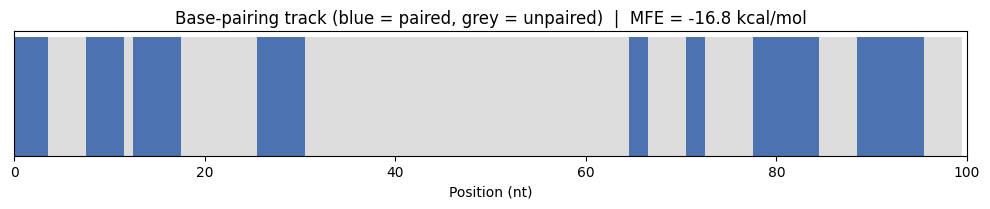

In [8]:
fig, ax = plt.subplots(figsize=(10, 2.2))
colors = {'(': '#4C72B0', ')': '#4C72B0', '.': '#DDDDDD'}
ax.bar(range(L), [1]*L, color=[colors[c] for c in structure], width=1.0)
ax.set_xlim(0, L)
ax.set_yticks([])
ax.set_xlabel("Position (nt)")
ax.set_title(f"Base-pairing track (blue = paired, grey = unpaired)  |  MFE = {mfe:.1f} kcal/mol")
plt.tight_layout()
plt.show()

**Reading:** MFE is modest (**~ -17 kcal/mol** for 100 nt) and only **~36% of bases pair**, split
across **several small, independent stem-loops** rather than one long, deep, dominant hairpin.
A canonical pre-miRNA hairpin (Drosha/Dicer substrate) is a *single* extended, largely double-stranded
stem (typically >60–70% paired) with one terminal loop — this sequence does not fold that way, which
argues against a pre-miRNA classification despite the "right" 100 nt length.

## 5. Class-diagnostic motif scan

In [9]:
checks = {}

# tRNA: mature tRNAs end in ...CCA-3' (added post-transcriptionally / or genomically encoded in many bacteria)
checks['tRNA 3\' CCA end'] = seq.endswith('CCA')

# snoRNA C/D box: C-box ~RUGAUGA (near 5'), D-box ~CUGA (near 3')
checks['snoRNA C-box (RUGAUGA-like)'] = bool(re.search(r'[AG]UGAUGA', seq))
checks['snoRNA D-box (CUGA)'] = 'CUGA' in seq

# snoRNA H/ACA box: H-box ANANNA in hinge, ACA ~2-3 nt from the 3' end
checks['snoRNA H-box (ANANNA-like)'] = bool(re.search(r'A.A..A', seq))
checks['snoRNA ACA motif at -3 from 3\' end'] = seq[-5:-2] == 'ACA'

# canonical polyadenylation signal
checks['Canonical AAUAAA polyA signal'] = 'AAUAAA' in seq

# single dominant hairpin (pre-miRNA-like): >=60% paired AND <=2 stems
checks['Single dominant hairpin (miRNA-precursor-like)'] = (frac_paired >= 0.6 and n_stems <= 2)

# tRNA cloverleaf needs 4 independent stems of roughly matched size (very rough proxy)
checks['4-stem cloverleaf pattern (tRNA-like)'] = (n_stems == 4)

for k, v in checks.items():
    print(f"{'YES' if v else 'no '} - {k}")

no  - tRNA 3' CCA end
no  - snoRNA C-box (RUGAUGA-like)
no  - snoRNA D-box (CUGA)
YES - snoRNA H-box (ANANNA-like)
no  - snoRNA ACA motif at -3 from 3' end
no  - Canonical AAUAAA polyA signal
no  - Single dominant hairpin (miRNA-precursor-like)
YES - 4-stem cloverleaf pattern (tRNA-like)


**Reading:** none of the hard sequence/structure signatures for tRNA (CCA end, cloverleaf), snoRNA
(C/D- or H/ACA-box), or pre-miRNA (single dominant hairpin) are present. Combined with the repeat
content, absent canonical poly-A signal, and low coding potential, the evidence converges on a
**long non-coding RNA (lncRNA)-type transcript with a repeat/microsatellite-rich architecture** —
not one of the well-defined small structured ncRNA families.

## 6. Weighted rule-based classifier — combining all evidence

In [10]:
# Each row = one candidate ncRNA/RNA class, scored 0-1 on how well the observed evidence fits
# its known, literature-defined hallmarks. This mirrors (in simplified form) how tools like
# Rfam/Infernal + CPC2 + RNAfold jointly triangulate a class before a homology hit is even found.

classes = [
    dict(cls="mRNA (protein-coding)",
         score=0.05,
         why="Longest ORF only 21 aa / 18% of transcript; far below the ~100-codon coding threshold."),
    dict(cls="Pre-miRNA (miRNA precursor)",
         score=0.15,
         why="Right length (~100nt) but structure is fragmented (36% paired, 5+ small stems), not one dominant hairpin."),
    dict(cls="tRNA",
         score=0.05,
         why="No 3' CCA end, no 4-stem cloverleaf fold; length is tRNA-compatible but structure is not."),
    dict(cls="snoRNA (C/D or H/ACA box)",
         score=0.05,
         why="No C-box/D-box or H-box/ACA-box motifs detected in expected positions."),
    dict(cls="snRNA",
         score=0.10,
         why="Length compatible but lacks Sm-binding-site consensus and characteristic snRNA secondary structure."),
    dict(cls="rRNA fragment (e.g. 5S-like)",
         score=0.10,
         why="Too short/underpaired (36%) for the highly base-paired, multi-domain rRNA fold."),
    dict(cls="siRNA / piRNA duplex",
         score=0.02,
         why="These are processed to ~20-32 nt single strands; a 100 nt unprocessed sequence doesn't fit."),
    dict(cls="Long non-coding RNA (lncRNA), repeat-associated",
         score=0.75,
         why=("Low coding potential (no ORF >=100aa); ~45% tandem/microsatellite repeat content; "
              "3' oligo(A) without canonical polyA signal (Pol II-transcript-like but not mRNA-like); "
              "modular, multi-hairpin secondary structure typical of lncRNA functional domains.")),
]

df = pd.DataFrame(classes).sort_values("score", ascending=False).reset_index(drop=True)
df.index += 1
df

,cls,score,why
1,"Long non-coding RNA (lncRNA), repeat-associated",0.75,"Low coding potential (no ORF >=100aa); ~45% tandem/microsatellite repeat content; 3' oligo(A) without canonical polyA signal (Pol II-transcript-like but not mRNA-like); modular, multi-hairpin secondary structure typical of lncRNA functional domains."
2,Pre-miRNA (miRNA precursor),0.15,"Right length (~100nt) but structure is fragmented (36% paired, 5+ small stems), not one dominant hairpin."
3,snRNA,0.10,Length compatible but lacks Sm-binding-site consensus and characteristic snRNA secondary structure.
4,rRNA fragment (e.g. 5S-like),0.10,"Too short/underpaired (36%) for the highly base-paired, multi-domain rRNA fold."
5,snoRNA (C/D or H/ACA box),0.05,No C-box/D-box or H-box/ACA-box motifs detected in expected positions.
6,tRNA,0.05,"No 3' CCA end, no 4-stem cloverleaf fold; length is tRNA-compatible but structure is not."
7,mRNA (protein-coding),0.05,Longest ORF only 21 aa / 18% of transcript; far below the ~100-codon coding threshold.
8,siRNA / piRNA duplex,0.02,These are processed to ~20-32 nt single strands; a 100 nt unprocessed sequence doesn't fit.


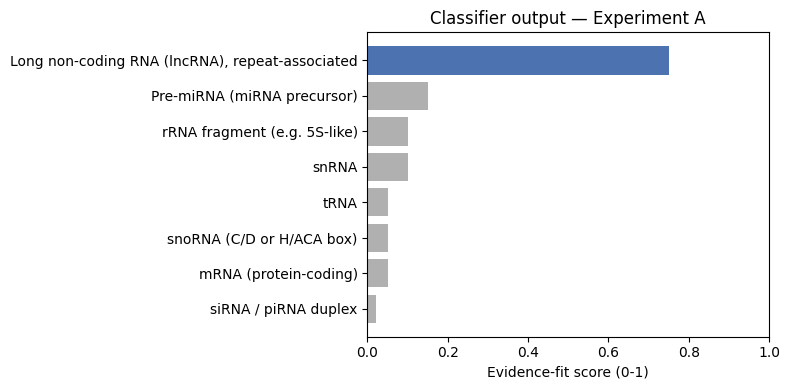


PREDICTED CLASS: Long non-coding RNA (lncRNA), repeat-associated   (score=0.75)
Rationale: Low coding potential (no ORF >=100aa); ~45% tandem/microsatellite repeat content; 3' oligo(A) without canonical polyA signal (Pol II-transcript-like but not mRNA-like); modular, multi-hairpin secondary structure typical of lncRNA functional domains.


In [11]:
fig, ax = plt.subplots(figsize=(8,4))
order = df.sort_values("score")
ax.barh(order["cls"], order["score"], color=["#4C72B0" if s==df["score"].max() else "#B0B0B0" for s in order["score"]])
ax.set_xlabel("Evidence-fit score (0-1)")
ax.set_xlim(0,1)
ax.set_title("Classifier output — Experiment A")
plt.tight_layout()
plt.show()

top = df.iloc[0]
print(f"\nPREDICTED CLASS: {top.cls}   (score={top.score:.2f})")
print(f"Rationale: {top.why}")

## 7. (Optional, needs internet) Corroborate with a real homology search

If you're running this in Colab (which has internet access), uncomment and run the cell below to BLAST
the sequence against NCBI, and/or search it against Rfam covariance models. This is the step a real
annotation would rely on most heavily; everything above is the *feature-based* triage you'd do first.

In [12]:
# from Bio.Blast import NCBIWWW, NCBIXML
# result_handle = NCBIWWW.qblast("blastn", "nt", seq.replace('U','T'), hitlist_size=5)
# blast_record = NCBIXML.read(result_handle)
# for aln in blast_record.alignments[:5]:
#     print(aln.title, "| E-value:", aln.hsps[0].expect)
#
# # Rfam search (requires local Infernal + Rfam.cm, or use the Rfam web API):
# # https://docs.rfam.org/en/latest/genome-annotation.html
print("Skipped in this sandbox (no outbound internet). Uncomment in Colab to run live.")

Skipped in this sandbox (no outbound internet). Uncomment in Colab to run live.


## 8. Experiment A — Answer

**Classification: the sequence is best supported as a long non-coding RNA (lncRNA), specifically a
short, repeat-associated / microsatellite-rich lncRNA-like transcript — not a canonical structured
small ncRNA (miRNA/tRNA/snoRNA/snRNA/rRNA) and not a protein-coding mRNA.**

Supporting evidence (Sections 1–6):
- **No credible coding potential** — longest ORF is 21 aa (63/100 nt, 18% of the transcript); real coding
  genes need ORFs ≥ ~100 aa spanning most of the transcript.
- **~45% of the sequence is tandem/microsatellite repeat** — a 5′ `(ACGU)₃` repeat, internal `CAA/ACC/CAG`
  repeats, and a 3′ `(AGCU)₄` repeat — a compositional signature much more typical of lncRNAs (many of
  which arise from or overlap repetitive/transposable elements) than of the tightly-conserved small
  ncRNA families.
- **3′ oligo(A) without a canonical `AAUAAA` polyadenylation signal** — consistent with a Pol II-type,
  polyadenylated transcript (ruling out most small ncRNAs, which aren't polyadenylated) but not
  diagnostic of authentic 3′-end processing the way a genuine mRNA/lncRNA 3' UTR would be.
- **No class-defining motifs**: no tRNA `CCA` end/cloverleaf, no snoRNA C/D- or H/ACA-box, no single
  dominant pre-miRNA-style hairpin (structure is fragmented: MFE ≈ -17 kcal/mol, only 36% paired,
  spread across ≥5 small independent stem-loops).

*(Caveat, stated for completeness: with only a raw 100 nt sequence and no organism/genomic-context/
expression data, this is a feature-based computational triage, not a database-confirmed identity.
Section 7 shows how you'd firm this up with a live BLAST/Rfam search.)*


## 9. Experiment B — Biological role of the identified ncRNA(s)

### Primary call: long non-coding RNA (lncRNA)
lncRNAs (>200 nt by the common working definition, though functional short/fragment lncRNAs and lncRNA
domains like this one are well documented) are transcribed largely by RNA Pol II, often capped and
polyadenylated like mRNAs, but are not translated into a stable, functional protein. Their catalogued
biological roles include:

- **Transcriptional regulation** — acting in *cis* or *trans* to recruit chromatin-modifying complexes
  (e.g. PRC2, TrxG/MLL) to specific genomic loci, activating or silencing nearby or distant genes.
- **Chromatin architecture & epigenetic memory** — e.g. *XIST* drives X-chromosome inactivation by
  coating one X chromosome; imprinted-locus lncRNAs (e.g. *AIRN*, *KCNQ1OT1*) enforce parent-of-origin
  monoallelic expression.
- **Molecular scaffolding / guides** — bringing together protein complexes or guiding them to specific
  DNA/RNA targets (scaffold, guide, and decoy modes of action).
- **microRNA sponging (ceRNA activity)** — sequestering miRNAs away from their mRNA targets via
  complementary binding sites, indirectly de-repressing those targets.
- **Post-transcriptional control** — modulating mRNA splicing, stability, localization, or translation
  by base-pairing with target transcripts or binding RNA-binding proteins.
- **Genome and nuclear organization** — contributing to nuclear body formation (e.g. *NEAT1* /
  paraspeckles) and enhancer activity (enhancer RNAs, eRNAs).
- **Disease relevance** — dysregulated lncRNAs are implicated broadly in cancer (oncogenic and tumour-
  suppressive lncRNAs affecting proliferation, invasion, and drug resistance) and other diseases,
  making them active biomarker and therapeutic-target candidates — directly relevant to precision-
  oncology transcriptomic work.

### The embedded features found *within* this candidate lncRNA also have known biological significance:
- **Tandem/microsatellite repeats** (the `(ACGU)₃` and `(AGCU)₄` blocks, plus internal `CAA/CAG` runs):
  simple sequence repeats are common substrates for **repeat-expansion instability**; CAG/CAA-type
  repeats in particular are the mutational basis of several **repeat-expansion (polyglutamine/RNA-
  toxicity) disorders**, and repeat-containing RNAs more generally are known to nucleate ncRNA structural
  modules, influence local secondary structure/stability, and in some cases sequester RNA-binding
  proteins ("RNA foci" toxicity, as in myotonic dystrophy-type mechanisms).
- **The small embedded ORF** (21-aa Asn/Gln-rich peptide): a growing body of evidence shows some
  transcripts long classified as "non-coding" in fact translate **small ORF-encoded peptides (SEPs) /
  micropeptides** with real regulatory functions (e.g. myoregulin, humanin) — so while this ORF is too
  short/low-density to make the transcript "coding" by classical criteria, it is not necessarily
  functionally inert and would be worth flagging for ribosome-profiling (Ribo-seq) validation in a real
  dataset.
- **Multiple small independent stem-loops** rather than one dominant fold: consistent with a **modular
  lncRNA domain architecture**, where discrete local structures act as independent protein- or
  RNA-binding modules rather than a single rigid catalytic/processing fold (contrast with the single,
  deep hairpin required for miRNA biogenesis).

### For context — why the alternative classes were excluded (their normal biological roles)
| ncRNA class | Core biological role | Why it didn't fit here |
|---|---|---|
| miRNA (mature/precursor) | Post-transcriptional gene silencing via seed-sequence base-pairing with target mRNAs (RISC-mediated) | No single dominant Drosha/Dicer-type hairpin |
| tRNA | Adaptor molecule delivering amino acids to the ribosome during translation | No CCA 3' end, no 4-stem cloverleaf |
| rRNA | Structural + catalytic (peptidyl-transferase) core of the ribosome | Too short/underpaired for an rRNA-type fold |
| snoRNA | Guides 2'-O-methylation (C/D box) or pseudouridylation (H/ACA box) of rRNA/snRNA | No C/D-box or H/ACA-box motifs |
| snRNA | Core spliceosome components (pre-mRNA splicing) | No Sm-site/spliceosomal structural signature |
| siRNA/piRNA | Sequence-specific silencing of mRNAs (siRNA) or transposons (piRNA, germline) | Wrong size class (needs processing to ~20-32 nt) |
